In [ ]:
# For WIP and avoid re-executing individual cells, to be deleted...

#import warnings
#warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=DeprecationWarning)
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["PL_TORCH_DISTRIBUTED_BACKEND"] = "gloo"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
#from time import time
import joblib
from pathlib import Path
#from time import time
#from tqdm import tqdm
import copy
import matplotlib as mpl
import napari
#import colorcet as cc
#import composition_stats as cs
#from sklearn.impute import KNNImputer

#from sklearn.cluster import KMeans
#from sklearn.metrics import silhouette_samples, silhouette_score
#import matplotlib.cm as cm

from tysserand import tysserand as ty
from mosna import mosna

import matplotlib as mpl

: 

In [ ]:
file_name = 'aggregation_statistics_2000_genes.parquet'
save_dir = Path("./OUTPUT/niches/agreg")
var_aggreg = pd.read_parquet(save_dir / file_name)
np.isinf(var_aggreg.values).any()

In [3]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


#récup les stats dans un fichier sans cacluler dans fichier
file_name = 'aggregation_statistics_2000_genes.parquet'
save_dir = Path("./OUTPUT/niches/agreg")
var_aggreg = pd.read_parquet(save_dir / file_name)

# var_aggreg = DataFrame (rows = nodes, columns = features)

# 1. garder l'ordre des nodes
node_order = var_aggreg.index

# 2. (optionnel mais recommandé) standardisation
#X = StandardScaler().fit_transform(var_aggreg.values)

X = var_aggreg.values

# 3. PCA
pca = PCA(n_components=30)
pcs = pca.fit_transform(X)

# 4. reconstruire DataFrame avec mêmes index
pcs_df = pd.DataFrame(
    pcs,
    index=node_order,
    columns=[f"PC{i+1}" for i in range(30)]
)

: 

### Calcul des statistiques autour de chaque nodes

In [2]:

nodes_dir = Path('./nodes/nodes_with_genes/1000')
nodes = pd.read_parquet(nodes_dir / 'nodes_patient-01_sample-01.parquet')



In [3]:

nodes.iloc[:, 16:]

,A2ML1,ABCA6,ABCB1,ABCC9,ABI3BP,ACAP1,ACKR1,ACP5,ACTA2,ACTG2,...,ZNF331,ZNF365,ZNF385D,ZNF43,ZNF683,ZNF708,ZNF735,ZNF831,ZNF91,ZSCAN4
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689197,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
689198,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
689199,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
689200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
use_attributes = nodes.columns[16:]

In [5]:
len(use_attributes)

1000

In [6]:
niches_dir = Path("./OUTPUT/niches")
niches_dir.mkdir(exist_ok=True)



In [7]:

print(nodes.shape)
print(nodes.memory_usage(deep=True).sum() / 1024**2, "MB")

(689202, 1016)
2891.7836360931396 MB


In [22]:
type(nodes.values)

numpy.ndarray

In [8]:
print(nodes.dtypes)

cell_id                  object
x_centroid              float64
y_centroid              float64
transcript_counts         int64
control_probe_counts      int64
                         ...   
ZNF708                  float32
ZNF735                  float32
ZNF831                  float32
ZNF91                   float32
ZSCAN4                  float32
Length: 1016, dtype: object


In [8]:
print(nodes.shape)

(689202, 1016)


In [ ]:
# stats des neighbours autour d'un node
nodes_dir = Path('./nodes/nodes_with_genes/1000/')
edges_dir = Path('./OUTPUT/1000_edges_tysserand/')
stat_funcs='default'
stat_names='default'
#use_attributes = None
method = 'NAS'
id_level_1 = 'patient'
id_level_2 = 'sample'
col_coords = ["x_centroid", "y_centroid"]
attributes_col = nodes.columns
make_onehot = False
data_info = ['01','01']
read_fct = pd.read_parquet
extension = 'parquet'
parallel_groups = 6
memory_limit = '60GB'

var_aggreg = mosna.compute_spatial_omic_features_single_network(data_info = data_info,read_fct= read_fct, method=method,attributes_col= attributes_col, use_attributes= use_attributes, stat_funcs=stat_funcs,stat_names=stat_names, extension =extension,nodes_dir=nodes_dir, edges_dir=edges_dir, id_level_1 = id_level_1, id_level_2 =id_level_2, make_onehot = make_onehot)


                                             

In [31]:
var_aggreg

,A2M mean,A2ML1 mean,ABCA6 mean,ABCA8 mean,ABCA9 mean,ABCB1 mean,ABCC9 mean,ABCD2 mean,ABI3BP mean,ACAP1 mean,...,ZNF844 std,ZNF853 std,ZNF880 std,ZNF91 std,ZNF92 std,ZNF98 std,ZNRF1 std,ZSCAN4 std,patient,sample
0,0.000000,0.142857,0.000000,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,01,1
1,0.000000,0.000000,0.000000,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.349927,0.0,0.000000,0.0,01,1
2,0.000000,0.000000,0.000000,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.372678,0.0,0.000000,0.0,01,1
3,0.000000,0.571429,0.000000,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,01,1
4,0.000000,0.000000,0.000000,0.0,0.000,0.0,0.166667,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.372678,0.000000,0.0,0.372678,0.0,01,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76573,0.000000,2.625000,0.000000,0.0,0.125,0.0,0.000000,0.000000,0.125000,0.125000,...,0.0,0.0,0.0,0.330719,1.658312,0.0,0.661438,0.0,01,1
76574,0.000000,0.200000,0.000000,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,1.166190,0.0,01,1
76575,0.142857,0.000000,0.285714,0.0,0.000,0.0,0.000000,0.142857,0.428571,0.428571,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,01,1
76576,0.000000,0.500000,0.000000,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,01,1


In [25]:
# stats des neighbours autour d'un node
nodes_dir = Path('./nodes/nodes_with_genes/2000/9chunks_adjusted/')
edges_dir = Path('./OUTPUT/chunk_2000_edges_tysserand/')
stat_funcs='default'
stat_names='default'
#use_attributes = None
method = 'NAS'
id_level_1 = 'patient'
id_level_2 = 'sample'
col_coords = ["x_centroid", "y_centroid"]
attributes_col = nodes.columns
make_onehot = False
data_info = ['1','1']
read_fct = pd.read_parquet
extension = 'parquet'
parallel_groups = 7
memory_limit = '20GB'

var_aggreg = mosna.compute_spatial_omic_features_all_networks( method=method,attributes_col= attributes_col, use_attributes= use_attributes, stat_funcs=stat_funcs,stat_names=stat_names, extension =extension,nodes_dir=nodes_dir, edges_dir=edges_dir, id_level_1 = id_level_1, id_level_2 =id_level_2, make_onehot = make_onehot,parallel_groups = parallel_groups, memory_limit = memory_limit)


                                             

2026-06-29 16:53:06,937 - distributed.worker.memory - WARNING - Worker is at 94% memory usage. Pausing worker.  Process memory: 17.65 GiB -- Worker memory limit: 18.63 GiB
2026-06-29 16:53:06,954 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:33195 (pid=33132) exceeded 95% memory budget. Restarting...
2026-06-29 16:53:07,071 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:33195' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'compute_spatial_omic_features_single_network-3190f695-a9b6-4c9a-9cd3-0ff02a0bc8c5', 'compute_spatial_omic_features_single_network-3b07b686-7421-4f34-9e65-cc432a2c8f18', 'compute_spatial_omic_features_single_network-d87e4981-7f7a-474d-a667-b70ecc9c3ede', 'compute_spatial_omic_features_single_network-a26e9f17-6532-46ae-a90a-b16a46ad91bc'} (stimulus_id='handle-worker-cleanup-1782744787.0709558')
2026-06-29 16:53:07,320 - distributed.nanny - WARNING - Restarting worker
2026-06-29 16:54:47,6

KeyboardInterrupt: 

In [10]:
#enregistrer
save_dir = Path("./OUTPUT/niches/agreg")
save_dir.mkdir(exist_ok = True)
filename = save_dir / f'aggregation_statistics_2000_genes.parquet'
var_aggreg.to_parquet(filename, index=False)
                                             

In [7]:
var_aggreg

,B Cells mean,Cancer Associated Fibroblasts mean,Cytotoxic T Cells mean,Dendritic Cells mean,Differentiating Tumor Cells mean,Dyskeratotic Tumor Cells mean,Endocervical Ciliated Cells mean,Endocervical Columnar Cells mean,Endothelial Cells mean,Exhausted T Cells mean,...,Naive & Memory T Cells std,Neutrophils std,Parabasal Tumor Cells std,Plasma Cells std,Proliferative Parabasal Cells std,Regulatory T Cells std,Smooth Muscle std,Stroma & Smooth Muscle std,patient,sample
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,01,01
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,01,01
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,01,01
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.142857,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,01,01
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.166667,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,01,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689197,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,01,01
689198,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.372678,01,01
689199,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.433013,0.0,0.0,0.0,0.0,0.0,0.0,0.433013,01,01
689200,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.471405,01,01


In [ ]:
#récup les stats dans un fichier sans cacluler dans fichier
file_name = 'aggregation_statistics_2000_genes.parquet'
save_dir = Path("./OUTPUT/niches/agreg")
var_aggreg = pd.read_parquet(save_dir / file_name)



In [20]:
var_aggreg

,A2M mean,A2ML1 mean,ABCA6 mean,ABCA8 mean,ABCA9 mean,ABCB1 mean,ABCC9 mean,ABCD2 mean,ABI3BP mean,ACAP1 mean,...,ZNF844 std,ZNF853 std,ZNF880 std,ZNF91 std,ZNF92 std,ZNF98 std,ZNRF1 std,ZSCAN4 std,patient,sample
0,0.000000,0.142857,0.000,0.000000,0.0,0.000000,0.000000,0.00,0.000000,0.00,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,01,01
1,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,0.00,0.000000,0.00,...,0.0,0.000000,0.000000,0.000000,0.349927,0.0,0.000000,0.0,01,01
2,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,0.00,0.000000,0.00,...,0.0,0.000000,0.000000,0.000000,0.372678,0.0,0.000000,0.0,01,01
3,0.000000,0.571429,0.000,0.000000,0.0,0.000000,0.000000,0.00,0.000000,0.00,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,01,01
4,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.166667,0.00,0.000000,0.00,...,0.0,0.000000,0.000000,0.372678,0.000000,0.0,0.372678,0.0,01,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689197,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,0.00,0.166667,0.00,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,01,01
689198,0.500000,0.000000,0.000,0.000000,0.0,0.166667,0.166667,0.00,0.000000,0.00,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,01,01
689199,0.000000,0.000000,0.125,0.000000,0.0,0.000000,0.250000,0.25,0.500000,0.25,...,0.0,0.000000,0.330719,0.000000,0.000000,0.0,0.000000,0.0,01,01
689200,0.166667,0.000000,0.000,0.000000,0.0,0.000000,0.000000,0.00,0.166667,0.00,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,01,01


In [ ]:
#on récupère var aggreg clean et samples_info pour la suite
#var_aggreg_clean = var_aggreg.dropna()
#var_aggreg_samples_info = var_aggreg_clean[['patient', 'sample']]
var_aggreg_samples_info = var_aggreg[['patient', 'sample']].copy()

### Cell types : allignement des cell types dans un array avec le même ordre que nodes respectifs dans var_aggreg

description de la fonction utilisée mosna.aggregate_cell_types:
Aggregate cell types in the same order of patients and samples IDs as for the Neighbors Aggregation Statistics method.

In [22]:
#je récupère les cell_type de base


folder = Path("./nodes")
files = folder.glob("nodes_*")


all_dfs = []

for file in files:
    
    if "nodes" not in file.name:
        continue

    if file.suffix == ".csv":
        df = pd.read_csv(file)
    elif file.suffix == ".parquet":
        df = pd.read_parquet(file)
    elif file.suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(file)
    else:
        continue

    df["source_file"] = file.stem
    all_dfs.append(df)

big_nodes = pd.concat(all_dfs, ignore_index=True)

In [23]:
big_nodes

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,group,color,source_file
0,aaaaahkl-1,24.557163,356.760437,1896,0,2,1,0,0,1899,56.983010,38.741222,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,Hypoxic Tumor Cells,#B21318,nodes_patient-01_sample-01
1,aaaabeha-1,21.358480,371.641663,1737,0,0,0,0,0,1737,44.565952,34.677458,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,Hypoxic Tumor Cells,#B21318,nodes_patient-01_sample-01
2,aaaabmoe-1,27.345419,368.845734,2761,0,2,0,0,0,2763,84.074774,39.689434,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,Hypoxic Tumor Cells,#B21318,nodes_patient-01_sample-01
3,aaaacmod-1,16.825048,396.867096,2214,0,0,0,1,0,2215,54.680210,35.128987,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,Hypoxic Tumor Cells,#B21318,nodes_patient-01_sample-01
4,aaaafdoj-1,19.836916,407.070068,731,0,0,0,0,0,731,27.452987,25.150187,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,Hypoxic Tumor Cells,#B21318,nodes_patient-01_sample-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689197,oilnogad-1,4448.264160,8053.022461,129,0,0,0,0,0,129,10.972164,10.972164,1,Segmented by nucleus expansion of 5.0µm,Interstitial Fibroblasts,#8CB832,nodes_patient-01_sample-01
689198,oilnpgne-1,4229.632812,8223.905273,130,0,0,0,0,0,130,13.500729,13.500729,1,Segmented by nucleus expansion of 5.0µm,Interstitial Fibroblasts,#8CB832,nodes_patient-01_sample-01
689199,oiloadej-1,4362.335449,8084.934570,120,0,0,0,0,0,120,12.371906,12.371906,1,Segmented by nucleus expansion of 5.0µm,Naive & Memory T Cells,#1B93FF,nodes_patient-01_sample-01
689200,oiloeaao-1,3992.469238,8133.043945,244,0,0,0,0,0,244,40.863411,14.448941,1,Segmented by nucleus expansion of 5.0µm,Stroma & Smooth Muscle,#E4B11F,nodes_patient-01_sample-01


In [ ]:
#big_nodes = pd.concat([big_nodes, var_aggreg], axis=1)
#cell = big_nodes['group'].to_numpy()
#cell

array(['Hypoxic Tumor Cells', 'Hypoxic Tumor Cells',
       'Hypoxic Tumor Cells', ..., 'Naive & Memory T Cells',
       'Stroma & Smooth Muscle', 'Interstitial Fibroblasts'],
      shape=(689202,), dtype=object)

In [25]:
#Aggregate cell types in the same order of patients and samples IDs as for the Neighbors Aggregation Statistics method.

# à partir de colonne source_file, créé colonne patient et sample
big_nodes[["patient", "sample"]] = big_nodes["source_file"].str.extract(
    r"patient-(\d+)_sample-(\d+)"
)

big_nodes["patient"] = big_nodes["patient"].astype(int)
big_nodes["sample"] = big_nodes["sample"].astype(int)

#données pour la fonction mosna.aggregate_cell_types
cohort_data = big_nodes 
pheno_col = 'group'
patient_col = 'patient'
sample_col = 'sample'
file_name = "cell_types_aggreg_good_order.parquet"
nodes_dir = Path("./OUTPUT/niches/agreg")

# je mets en int car dans big_nodes c'est en int
var_aggreg_samples_info[patient_col] = var_aggreg_samples_info[patient_col].astype(int)
var_aggreg_samples_info[sample_col] = var_aggreg_samples_info[sample_col].astype(int)


#renvoie array avec les cell type allignés 
cell_types = mosna.aggregate_cell_types(
    var_aggreg_samples_info = var_aggreg_samples_info,
    cohort_data = cohort_data,
    pheno_col = pheno_col,
    patient_col = patient_col,
    sample_col = sample_col,
    save_data = True,
    file_name = file_name,
    nodes_dir = nodes_dir,
    force_recompute = True
    )

Aggregating cell types in correct order


1it [00:00, 130.55it/s]

Concatenated 689202 cells


### Réduction et clustering

In [7]:

#Pour le clustering 



cluster_params = {
    'reducer_type' : 'umap',
   'clusterer_type':'leiden',
   'n_clusters':7,
   'force_recompute' : True,
   'resolution' : 0.1,
   #n_neighbors = neighbors dans umap et k_cluster = neighbors dans kmm
   'n_neighbors' :20,
   'k_cluster' : 15
   #résolution que pour leiden
   
}

In [5]:
#récup les stats par nodes dans un fichier sans cacluler dans fichier
file_name = 'aggregation_statistics_2000_genes.parquet'
save_dir = Path("./OUTPUT/niches/agreg")
var_aggreg = pd.read_parquet(save_dir / file_name)

In [9]:
#var_aggreg_clean = var_aggreg.dropna()
var_aggreg_clean = (
    var_aggreg.drop(columns=['patient', 'sample'])
)

In [29]:
#récup les cell types sans calculer si dans fichier

save_dir = Path("./OUTPUT/niches/agreg")
cell_types = np.load(save_dir / f'cell_types_aggreg_good_order.parquet.npy',allow_pickle=True)


In [10]:
#réduction et clustering 

data_dir = Path("./OUTPUT/niches/results_niche/")
data_dir.mkdir(exist_ok= True)

labels, cluster_dir, n_clust, _, = mosna.get_clusterer(
    data=var_aggreg_clean.values,
    data_dir=data_dir,
    n_neighbors = cluster_params['n_neighbors'],
    reducer_type=cluster_params['reducer_type'],
    clusterer_type=cluster_params['clusterer_type'],
    n_clusters=cluster_params['n_clusters'],
    force_recompute=cluster_params['force_recompute'],
    resolution=cluster_params['resolution'],
    k_cluster = cluster_params['k_cluster'],
    use_gpu=False
)

Computing dimensionality reduction


: 

In [ ]:


def get_reducer_dir_name(cluster_params, reducer_dir_name):
    #fonction pour récupérer le nom du dossier cluster
    #cluster_params = dico
    #reducer dir name = str
    if cluster_params["clusterer_type"] == 'leiden':
        n_neighbors = str(cluster_params["n_neighbors"])
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    elif cluster_params["clusterer_type"] == 'spectral' or cluster_params["clusterer_type"] == 'ecg':
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    else : 
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}'
    return clusterer_dir_name

In [ ]:
# charger les labels sans recalculer
#file name = nom du fichier avec les labels
reducer_dir_name = "reducer-umap_dim-2_nneigh-15_metric-manhattan_min_dist-0.0"
clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name) 

labels_file_name = 'leiden_resolution-0.05_labels.npy'


chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}'
chemin = Path(chemin)
labels = np.load(chemin/labels_file_name)

In [ ]:
nodes_cluster_labeled

,Object,89Y-Collagen-I,142Nd-CA9,143Nd-Vimentin,144Nd-CD14,145Nd-CD31,146Nd-CD11b,147Sm-CD163,148Nd-Pan-Keratin,149Sm-CD15,...,198Pt-ICSK3,209Bi-aSMA,Phenotype,area,centroid-0,centroid-1,axis_major_length,axis_minor_length,eccentricity,source_file
0,1,0.0,1.0000,2.2100,1.6530,0.0000,0.0,0.0,14.0930,0.0,...,26.1290,1.000000,Epithelial Cell,9,0.777778,434.666667,3.781743,3.130045,0.561211,nodes_patient-04_sample-05
1,2,0.0,0.0000,11.4360,0.6530,1.7145,0.0,0.0,0.0000,0.0,...,6.8440,8.691500,DC,6,0.000000,610.500000,6.831301,0.000000,1.000000,nodes_patient-04_sample-05
2,3,1.0,0.0000,1.0000,0.0000,0.0000,0.0,0.0,0.0000,0.0,...,2.0000,2.641000,Unknown,9,0.444444,619.777778,5.274258,1.946056,0.929440,nodes_patient-04_sample-05
3,4,1.0,1.3615,1.2910,0.0000,0.0000,0.0,0.0,3.2615,0.0,...,5.7965,11.424499,Epithelial Cell,12,0.916667,743.166667,4.894994,2.969311,0.795006,nodes_patient-04_sample-05
4,5,0.0,1.0000,0.0000,1.1065,0.0000,0.0,0.0,26.6710,0.0,...,11.1705,2.164000,Epithelial Cell,12,0.916667,982.416667,5.044025,3.000375,0.803846,nodes_patient-04_sample-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11480,11659,0.0,0.0000,1.3055,0.0000,0.0000,0.0,0.0,0.0000,0.0,...,1.5485,2.638500,Unknown,8,1659.500000,651.500000,4.472136,2.000000,0.894427,nodes_patient-04_sample-03
11481,11660,0.0,0.0000,4.2065,0.0000,0.0000,0.0,0.0,0.0000,0.0,...,1.0130,10.627000,CAF,8,1659.500000,1161.500000,4.472136,2.000000,0.894427,nodes_patient-04_sample-03
11482,11661,0.0,0.0000,1.0000,0.0000,0.0000,0.0,0.0,0.0000,0.0,...,0.0000,1.051000,Unknown,5,1659.600000,31.800000,3.098387,1.788854,0.816497,nodes_patient-04_sample-03
11483,11662,0.0,1.0000,2.1190,1.4020,0.0000,0.0,0.0,0.0000,0.0,...,0.0000,1.000000,CD4 T Cell,3,1660.000000,670.000000,3.265986,0.000000,1.000000,nodes_patient-04_sample-03


In [ ]:
#Enregistre (sans dropna) un data frame avec les nodes et leur label niche, index n'est pas set à zéro
#(ici mets les lignes qui recup big nodes, comme ça sera sans colone patient salmple en doukble)
reducer_dir_name = "reducer-umap_dim-2_nneigh-15_metric-manhattan_min_dist-0.0"
clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT'
save_dir = Path(chemin)
save_dir.mkdir(exist_ok = True)

folder = Path("./nodes")
files = folder.glob("nodes_*")




all_dfs = []

for file in files:
    
    if "nodes" not in file.name:
        continue

    if file.suffix == ".csv":
        df = pd.read_csv(file)
    elif file.suffix == ".parquet":
        df = pd.read_parquet(file)
    elif file.suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(file)
    else:
        continue

    df["source_file"] = file.stem
    all_dfs.append(df)



nodes_cluster_labeled = pd.concat(all_dfs, ignore_index=True)

#nodes_cluster_labeled = pd.concat([big_nodes, var_aggreg], axis=1)


#print(nodes_cluster_labeled[['patient','sample','source_file']])
#nodes_cluster_labeled = nodes_cluster_labeled.reset_index()
#supprime les colonnes en dupliqué et garde que premier qu'il rencontre
#nodes_cluster_labeled = nodes_cluster_labeled.loc[:, ~nodes_cluster_labeled.columns.duplicated()]
nodes_cluster_labeled['Niche'] = labels
print(nodes_cluster_labeled[['source_file',"Niche",'Object']])

# crée tous les dossiers parents si besoin
save_dir.mkdir(parents=True, exist_ok=True)

nodes_cluster_labeled.to_parquet(save_dir/f'nodes_cluster_{cluster_params["clusterer_type"]}_labeled.parquet')

                       source_file  Niche  Object
0       nodes_patient-04_sample-05      9       1
1       nodes_patient-04_sample-05      9       2
2       nodes_patient-04_sample-05     26       3
3       nodes_patient-04_sample-05      9       4
4       nodes_patient-04_sample-05      9       5
...                            ...    ...     ...
543082  nodes_patient-04_sample-03      0   11659
543083  nodes_patient-04_sample-03      0   11660
543084  nodes_patient-04_sample-03      0   11661
543085  nodes_patient-04_sample-03      0   11662
543086  nodes_patient-04_sample-03      0   11663

[543087 rows x 3 columns]


### Génération des plots

In [ ]:
reducer_dir_name ='reducer-umap_dim-2_nneigh-15_metric-manhattan_min_dist-0.0'

In [30]:

#charger les embeddings
file_name = 'embedding.npy'
path = Path("./OUTPUT/niches/results_niche/reducer-umap_dim-2_nneigh-20_metric-manhattan_min_dist-0.0")
embed_viz = np.load(path/file_name)
embed_viz

array([[12.232198  ,  4.0132065 ],
       [12.049282  ,  1.8385512 ],
       [12.421988  , -0.33261946],
       ...,
       [13.009943  , -2.27994   ],
       [13.189671  , -1.9435331 ],
       [13.164063  , -1.7369512 ]], shape=(543087, 2), dtype=float32)

In [31]:
# charger les labels sans recalculer
#file name = nom du fichier avec les labels
clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name) 

labels_file_name = 'leiden_resolution-0.05_labels.npy'


chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/'
chemin = Path(chemin)
labels = np.load(chemin/labels_file_name)

In [32]:
#récupérer un dico avec les params qui vont s'afficher dans nom des fichiers plots

if cluster_params['clusterer_type'] == 'gmm' or cluster_params['clusterer_type'] == 'spectral':
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type'],
      'n_clusters': cluster_params['n_clusters']
   }  
elif cluster_params['clusterer_type'] == 'leiden':
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type'],
      'res': str(cluster_params['resolution'])
   }
else:
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type']
   }


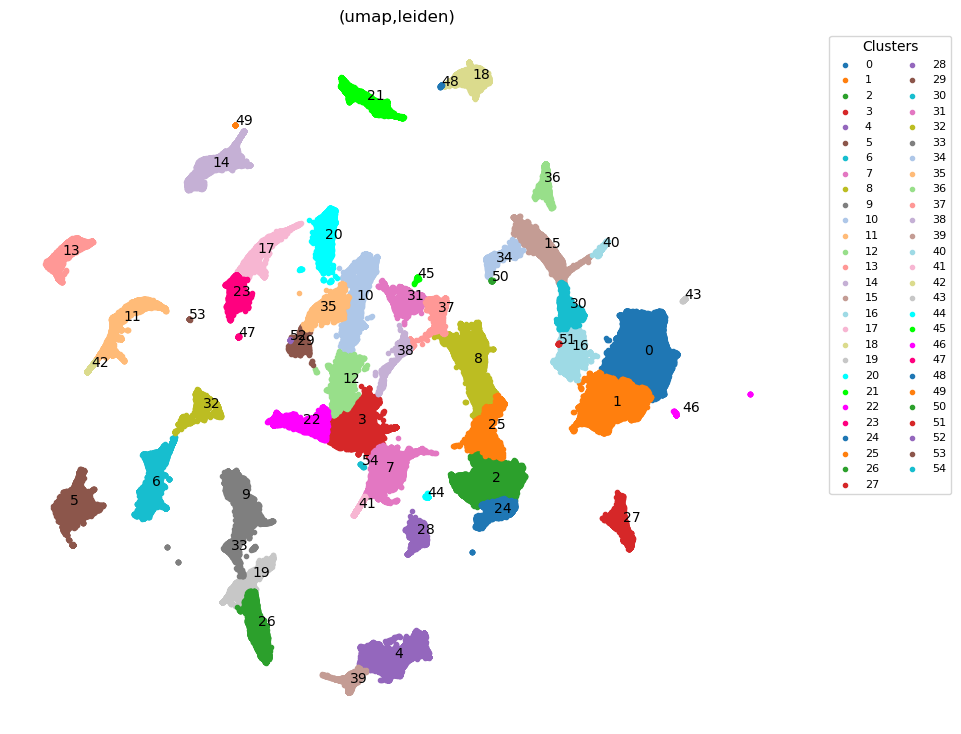

In [37]:
#plot les clusters

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT'
save_dir = Path(chemin)
save_dir.mkdir(exist_ok=True)


extra_str = ''

legend_opt = {
    'title': 'Clusters',
    'ncol': 2,
    'fontsize': 8,
    'title_fontsize': 10,
    'bbox_to_anchor': (1.05, 1),
    'loc': 'upper left'
}




# file name du plot après save de la forme =  f'cluster_labels{str_params}{extra_str}.png'
#cluster_params = dic, les paramètres utilisés pour clusterisation,
#  extra_str est ajouté à la fin du nom avant extension en info complémentaire

ax = mosna.plot_clusters(embed_viz = embed_viz, 
                  cluster_labels= labels,
                  save_dir=save_dir,
                  cluster_params=cluster_params_plot,
                  extra_str=extra_str, 
                  legend_opt =legend_opt
             )

fig = ax.get_figure()
ax.set_title(f"({cluster_params['reducer_type']},{cluster_params['clusterer_type']})")


if cluster_params_plot is None:
    str_params = ''
else:
    str_params = '_' + '_'.join([str(key) + '-' + str(val) for key, val in cluster_params_plot.items()])

figname =  f'cluster_labels{str_params}{extra_str}.png'
plt.savefig(save_dir / figname, bbox_inches="tight", dpi=150)

Composition 

In [39]:
#récup les cell types sans calculer si dans fichier

save_dir = Path("./OUTPUT/niches/agreg")
cell_types = np.load(save_dir / f'cell_types_aggreg_good_order.parquet.npy',allow_pickle=True)

In [40]:
# je récup la composition des niches,cette fonction  Make a counts matrix of cell types composition of niches.
normalize = ['Total','obs', 'niche','obs&niche','clr']
niches = labels
var = cell_types

#infos pour le plot :

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT/'
save_dir = Path(chemin)

for normalize in normalize:
    # je récup la composition des niches,cette fonction  Make a counts matrix of cell types composition of niches.
    counts = mosna.make_niches_composition(var = var, niches =niches, normalize = normalize)
    #plot niches Aggregated composition utilise 'counts'

    figsize = None
    plt.figure(figsize=(15,10))
    fig = sns.heatmap(counts, linewidths=.5, cmap=sns.color_palette("Blues", as_cmap=True),
                        xticklabels=True, yticklabels=True)
    fig.set_title('Niches Aggregated composition')
    fig.set_xlabel("Niches")
    fig.set_ylabel("Clusters")

    if cluster_params['clusterer_type'] == 'leiden':
        plt.savefig(save_dir/f"{normalize}_normalization_niches_res_{cluster_params['resolution']}_{cluster_params['clusterer_type']}.png")
    else : 
        plt.savefig(save_dir/f"{normalize}_normalization_niches_{cluster_params['clusterer_type']}.png")
    plt.close()

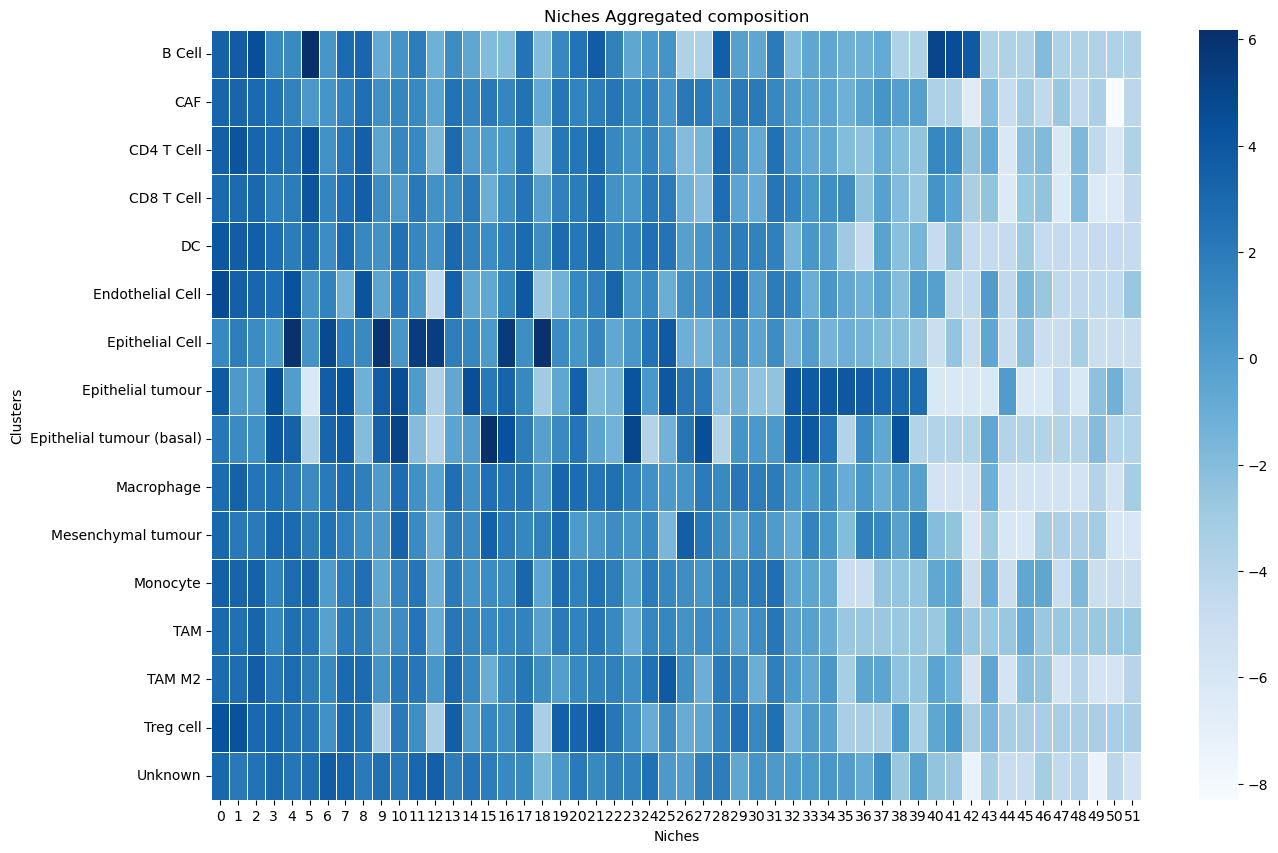

In [73]:
#plot niches Aggregated composition utilise 'counts'


clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT/'
save_dir = Path(chemin)

figsize = None
plt.figure(figsize=(15,10))
fig = sns.heatmap(counts, linewidths=.5, cmap=sns.color_palette("Blues", as_cmap=True),
                      xticklabels=True, yticklabels=True)
fig.set_title('Niches Aggregated composition')
fig.set_xlabel("Niches")
fig.set_ylabel("Clusters")

if cluster_params['clusterer_type'] == 'leiden':
    plt.savefig(save_dir/f"{normalize}_normalization_niches_res_{cluster_params['resolution']}_{cluster_params['clusterer_type']}.png")
else : 
    plt.savefig(save_dir/f"{normalize}_normalization_niches_{cluster_params['clusterer_type']}.png")

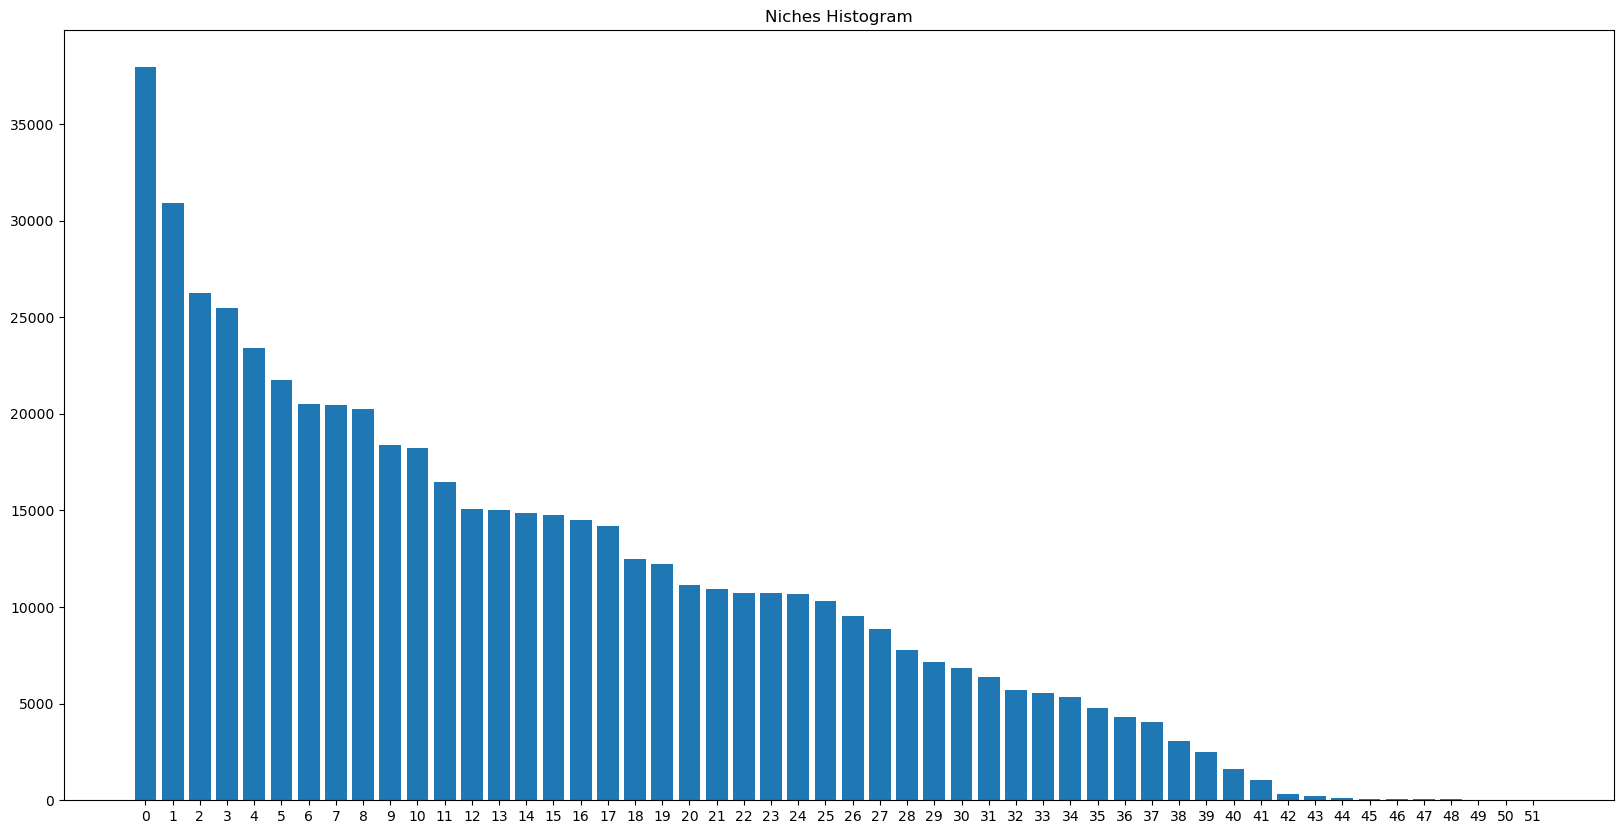

In [ ]:
#histogram combien de cell par niche

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT/'
save_dir = Path(chemin)

figsize =None
fig, ax = plt.subplots(figsize=(20,10))
niche_id, niche_count = np.unique(niches, return_counts=True)
ax.bar(niche_id, niche_count, width=0.8)
ax.set_xticks(niche_id)
ax.set_title('Niches Histogram')

if cluster_params['clusterer_type'] == 'leiden':
    plt.savefig(save_dir/f'niches_res_{cluster_params["resolution"]}__{cluster_params["clusterer_type"]}_histogram.png',bbox_inches="tight")
else : 
    plt.savefig(save_dir/f'niches_{cluster_params["clusterer_type"]}_histogram.png',bbox_inches="tight")


## Cluster merging

In [38]:
#Pour le clustering 



cluster_params = {
    'reducer_type' : 'umap',
   'clusterer_type':'leiden',
   'n_clusters':7,
   'force_recompute' : False,
   'resolution' : 0.05,
   #n_neighbors = neighbors dans umap et k_cluster = neighbors dans kmm
   'n_neighbors' :20,
   'k_cluster' : 15
   #résolution que pour leiden
   
}

In [39]:
reducer_dir_name ='reducer-umap_dim-2_nneigh-20_metric-manhattan_min_dist-0.0'
#charger les embeddings
file_name = 'embedding.npy'
path = Path("./OUTPUT/niches/results_niche/reducer-umap_dim-2_nneigh-20_metric-manhattan_min_dist-0.0")
embed_viz = np.load(path/file_name)
embed_viz

array([[12.232198  ,  4.0132065 ],
       [12.049282  ,  1.8385512 ],
       [12.421988  , -0.33261946],
       ...,
       [13.009943  , -2.27994   ],
       [13.189671  , -1.9435331 ],
       [13.164063  , -1.7369512 ]], shape=(543087, 2), dtype=float32)

In [ ]:


def get_reducer_dir_name(cluster_params, reducer_dir_name):
    #fonction pour récupérer le nom du dossier cluster
    #cluster_params = dico
    #reducer dir name = str
    if cluster_params["clusterer_type"] == 'leiden':
        n_neighbors = str(cluster_params["n_neighbors"])
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    elif cluster_params["clusterer_type"] == 'spectral' or cluster_params["clusterer_type"] == 'ecg':
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    else : 
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}'
    return clusterer_dir_name

In [40]:
#récupérer un dico avec les params qui vont s'afficher dans nom des fichiers plots

if cluster_params['clusterer_type'] == 'gmm' or cluster_params['clusterer_type'] == 'spectral':
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type'],
      'n_clusters': cluster_params['n_clusters']
   }  
elif cluster_params['clusterer_type'] == 'leiden':
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type'],
      'res': str(cluster_params['resolution'])
   }
else:
   cluster_params_plot = {
      'clusterer_type': cluster_params['clusterer_type']
   }


In [ ]:
# charger les labels à merger sans recalculer
#file name = nom du fichier avec les labels
clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name) 

labels_file_name = 'leiden_resolution-0.05_labels.npy'


chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/'
chemin = Path(chemin)
labels = np.load(chemin/labels_file_name)

In [ ]:

clusters = labels

n_neigh_max = 10
#charger les embeddings
file_name = 'embedding.npy'
path = Path("./OUTPUT/niches/results_niche/reducer-umap_dim-2_nneigh-20_metric-manhattan_min_dist-0.0")
embed_viz = np.load(path/file_name)

#save_dir où enregistrer labels merged
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'
save_dir = Path(chemin)
save_dir.mkdir(exist_ok=True)


coords = embed_viz
cond_n_clust = None

#pour merge cluster
"""
    Merge iteratively the smallest cluster to it's closest cluster 
    if its size is lower than a given size, until no further merging
    occurs or until a condition is reached.

    Parameters
    ----------
    clusters : np.array
        Cluster labels.
    coords : np.ndarray
        Coordinates of points in clusters.
    cond_n_clust: Union[int, None], None
        Sufficient condition on the number of clusters below which the iterative
        merge stops.
    force_n_clust : bool, False
        If True, force merging until the desired number of clusters is reached.
        It overides the 'until no further merging occurs' condition.
    size_thresh : Union[int, None], None
        If provided, the size threshold to merge the smallest cluster.
        If none, computed as the base size * ratio_size
    size_perc : int, 25
        Percentile of cluster size as the base size used for the size threshold.
    ratio_size : float, 0.1
        Ratio to compute size_thresh.
    n_neigh_max : int, 10
        Number of points to consider inside the cluster to merge for the closest neighbor.
    relabel_clusters_ids : bool, True
        If True, relabel N clusters between 0 and N-1.
    verbose : int, 1
        Verbosity level.
    
    Returns
    -------
    clusters : np.array
        Potentially merged clusters.
    """

labels_merged = mosna.merge_clusters_until(
    clusters = clusters,
    coords = coords,
    cond_n_clust = cond_n_clust,
    n_neigh_max =n_neigh_max
    )

np.save(save_dir/"labels_merged.npy", labels_merged)


cluster 53 merged with cluster 11
cluster 54 merged with cluster 7
cluster 52 merged with cluster 29
cluster 51 merged with cluster 16
cluster 50 merged with cluster 34
cluster 49 merged with cluster 14
cluster 48 merged with cluster 18
cluster 47 merged with cluster 23
cluster 46 merged with cluster 0
cluster 45 merged with cluster 31
cluster 44 merged with cluster 28
cluster 43 merged with cluster 0
no further merging can occur


In [88]:
#Enregistre (sans dropna) un data frame avec les nodes et leur label niche, index n'est pas set à zéro
#(ici mets les lignes qui recup big nodes, comme ça sera sans colone patient salmple en doukble)
reducer_dir_name = "reducer-umap_dim-2_nneigh-20_metric-manhattan_min_dist-0.0"
clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'
save_dir = Path(chemin)

folder = Path("./data/phenograph_clustering/nodes_phenotyped")
files = folder.glob("nodes_*")




all_dfs = []

for file in files:
    
    if "nodes" not in file.name:
        continue

    if file.suffix == ".csv":
        df = pd.read_csv(file)
    elif file.suffix == ".parquet":
        df = pd.read_parquet(file)
    elif file.suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(file)
    else:
        continue

    df["source_file"] = file.stem
    all_dfs.append(df)



nodes_cluster_labeled = pd.concat(all_dfs, ignore_index=True)

#nodes_cluster_labeled = pd.concat([big_nodes, var_aggreg], axis=1)


#print(nodes_cluster_labeled[['patient','sample','source_file']])
#nodes_cluster_labeled = nodes_cluster_labeled.reset_index()
#supprime les colonnes en dupliqué et garde que premier qu'il rencontre
#nodes_cluster_labeled = nodes_cluster_labeled.loc[:, ~nodes_cluster_labeled.columns.duplicated()]
nodes_cluster_labeled['Niche'] = labels_merged
print(nodes_cluster_labeled[['source_file',"Niche",'Object']])

# crée tous les dossiers parents si besoin
save_dir.mkdir(parents=True, exist_ok=True)

nodes_cluster_labeled.to_parquet(save_dir/f'nodes_cluster_{cluster_params["clusterer_type"]}_labeled.parquet')

                       source_file  Niche  Object
0       nodes_patient-04_sample-05      8       1
1       nodes_patient-04_sample-05      8       2
2       nodes_patient-04_sample-05     25       3
3       nodes_patient-04_sample-05      8       4
4       nodes_patient-04_sample-05      8       5
...                            ...    ...     ...
543082  nodes_patient-04_sample-03      2   11659
543083  nodes_patient-04_sample-03      2   11660
543084  nodes_patient-04_sample-03      2   11661
543085  nodes_patient-04_sample-03      2   11662
543086  nodes_patient-04_sample-03      2   11663

[543087 rows x 3 columns]


In [41]:
# load labels_merged sans charger :
#save_dir où sont enregistrées labels merged
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'
save_dir = Path(chemin)

file_name = 'labels_merged.npy'

labels_merged = np.load(save_dir/file_name)



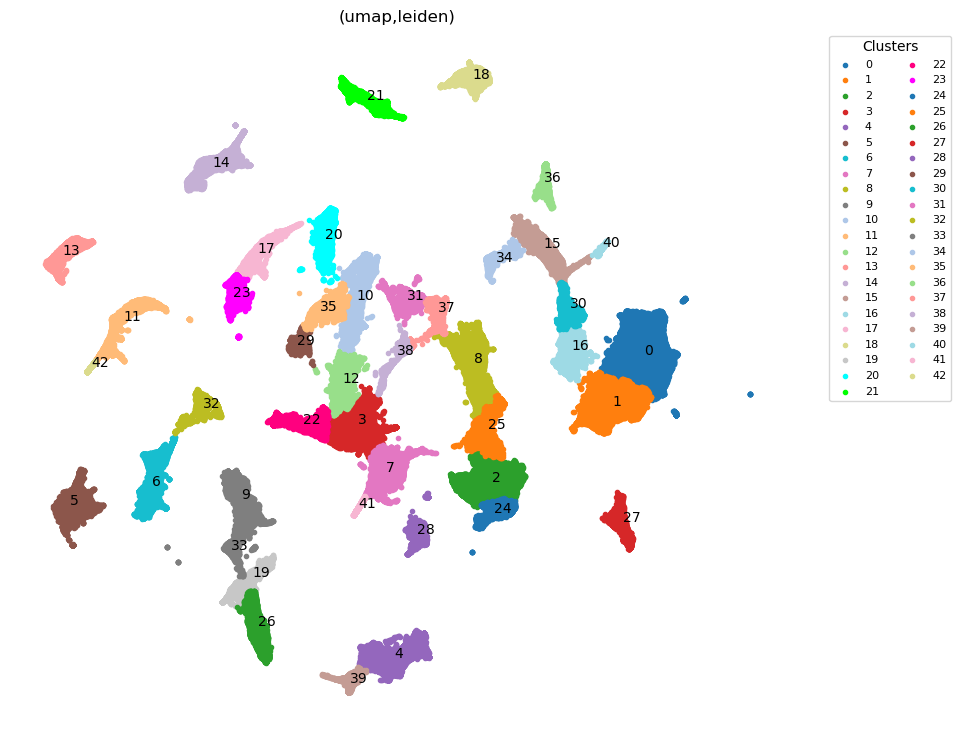

In [42]:

# pour plot
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'
save_dir = Path(chemin)
save_dir.mkdir(exist_ok=True)


extra_str='merged'

legend_opt = {
    'title': 'Clusters',
    'ncol': 2,
    'fontsize': 8,
    'title_fontsize': 10,
    'bbox_to_anchor': (1.05, 1),
    'loc': 'upper left'
}


ax = mosna.plot_clusters(
    embed_viz = embed_viz,
    cluster_labels = labels_merged,
    save_dir = save_dir,
    cluster_params=cluster_params_plot,
    extra_str=extra_str,
    legend_opt = legend_opt
    )
fig = ax.get_figure()
ax.set_title(f"({cluster_params['reducer_type']},{cluster_params['clusterer_type']})")

if cluster_params_plot is None:
    str_params = ''
else:
    str_params = '_' + '_'.join([str(key) + '-' + str(val) for key, val in cluster_params_plot.items()])

figname =  f'cluster_labels{str_params}{extra_str}.png'
plt.savefig(save_dir / figname, bbox_inches="tight", dpi=150)

In [80]:
#récup les cell types sans calculer si dans fichier

save_dir_cell_types = Path("./OUTPUT/niches/agreg")
cell_types = np.load(save_dir_cell_types / f'cell_types_aggreg_good_order.parquet.npy',allow_pickle=True)

In [81]:
# je récup la composition des niches,cette fonction  Make a counts matrix of cell types composition of niches.
normalize = ['Total','obs', 'niche','obs&niche','clr']
niches = labels_merged
var = cell_types

#infos pour le plot :

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'
save_dir = Path(chemin)

for normalize in normalize:
    # je récup la composition des niches,cette fonction  Make a counts matrix of cell types composition of niches.
    counts = mosna.make_niches_composition(var = var, niches =niches, normalize = normalize)
    #plot niches Aggregated composition utilise 'counts'

    figsize = None
    plt.figure(figsize=(15,10))
    fig = sns.heatmap(counts, linewidths=.5, cmap=sns.color_palette("Blues", as_cmap=True),
                        xticklabels=True, yticklabels=True)
    fig.set_title('Niches Aggregated composition')
    fig.set_xlabel("Niches")
    fig.set_ylabel("Clusters")

    if cluster_params['clusterer_type'] == 'leiden':
        plt.savefig(save_dir/f"{normalize}_normalization_niches_res_{cluster_params['resolution']}_{cluster_params['clusterer_type']}.png")
    else : 
        plt.savefig(save_dir/f"{normalize}_normalization_niches_{cluster_params['clusterer_type']}.png")
    plt.close()

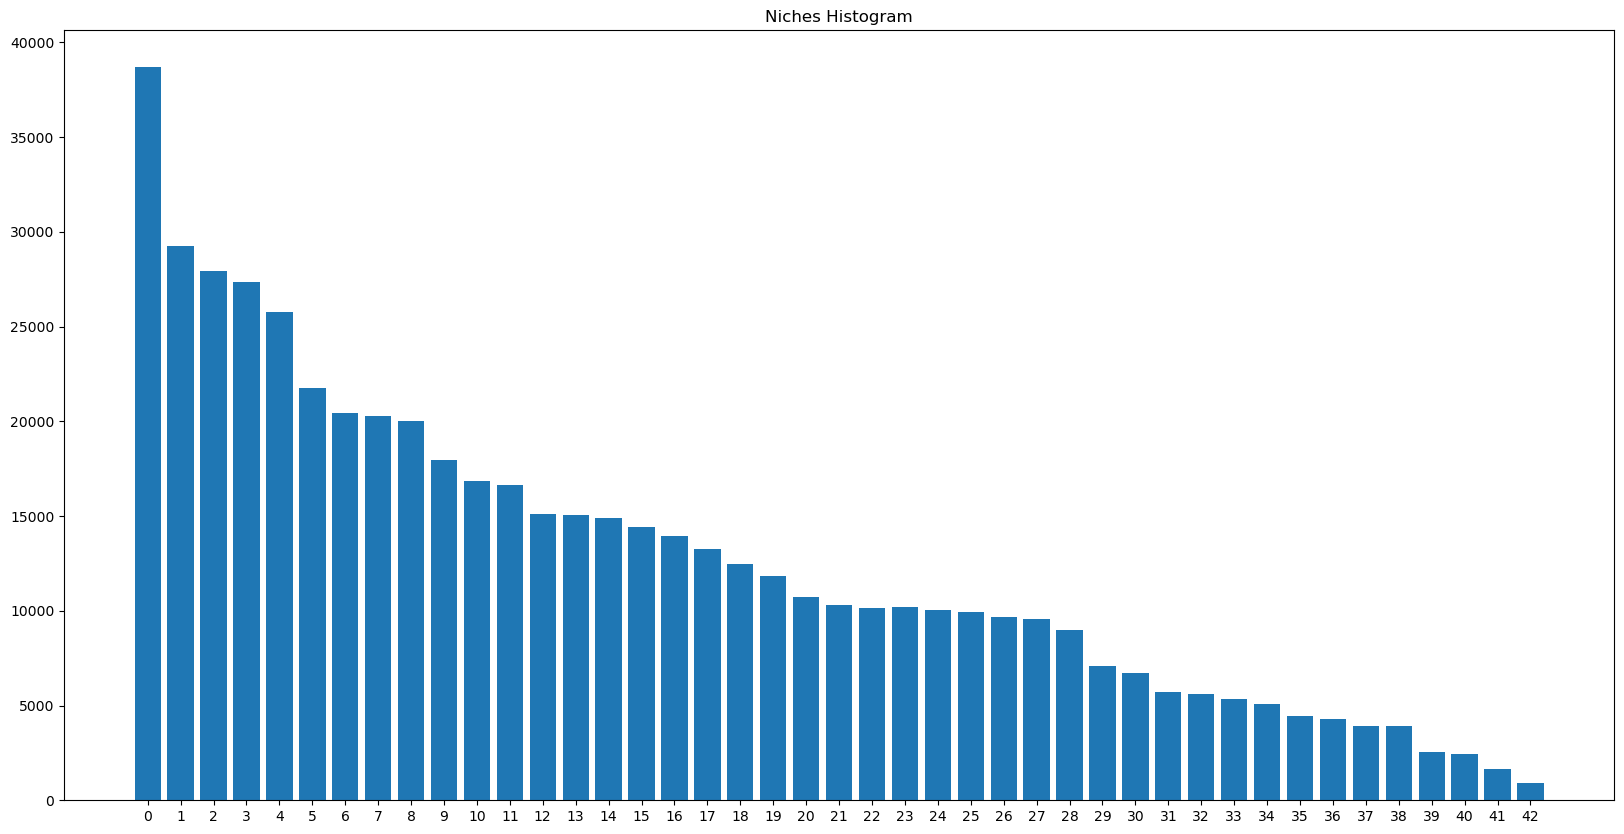

In [82]:
#histogram combien de cell par niche

clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)
chemin = f'./OUTPUT/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged'
save_dir = Path(chemin)

figsize =None
fig, ax = plt.subplots(figsize=(20,10))
niche_id, niche_count = np.unique(niches, return_counts=True)
ax.bar(niche_id, niche_count, width=0.8)
ax.set_xticks(niche_id)
ax.set_title('Niches Histogram')

if cluster_params['clusterer_type'] == 'leiden':
    plt.savefig(save_dir/f'niches_res_{cluster_params["resolution"]}__{cluster_params["clusterer_type"]}_histogram.png',bbox_inches="tight")
else : 
    plt.savefig(save_dir/f'niches_{cluster_params["clusterer_type"]}_histogram.png',bbox_inches="tight")
